<a href="https://colab.research.google.com/github/sthepaut/SAFRAN_ENSAI_2025/blob/ENSAI_students/performancemodel_ENSAI/notebook/genetic_algorithm_simple_simulation_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !git clone https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025
!git clone -b ENSAI_students https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025


fatal: destination path 'SAFRAN_ENSAI_2025' already exists and is not an empty directory.


In [2]:
# Verify that we have sucessfully clone the repo and go the place where the repo is stored
%cd /content/SAFRAN_ENSAI_2025
!ls


/content/SAFRAN_ENSAI_2025
Cie_0_Engine0.csv	performancemodel_ENSAI.zip
performancemodel_ENSAI	README.md


In [3]:
# install the package performance_model
%cd /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/
!pip install .

/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
Processing /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for performancemodel: filename=performancemodel-0.0.1-py3-none-any.whl size=31132 sha256=91e8917ddb1d7948e4d37793c97429a1c6ebe036614122908ce5a51766acdfb1
  Stored in directory: /tmp/pip-ephem-wheel-cache-vsgr663q/wheels/b4/6e/66/25433221b4a4d2ead6faf834b0fa81054260e4a8996e629ab9
Successfully built performancemodel
  Attempting uninstall: performancemodel
    Found existing installation: performancemodel 0.0.1
    Uninstalling performancemodel-0.0.1:
      Successfully uninstalled performancemodel-0.0.1


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

from performancemodel.base_system import h_SCSF
from performancemodel.scenarios import simulate_degradation_trajectory, generate_multiple_trajectories
from performancemodel.plot import plot_trajectory



In [22]:
import sys

import GA
from GA import GeneticAlgorithm



In [23]:

from GA_plots import plot_convergence_seaborn,plot_diversity_and_distribution,plot_ga_seaborn


#Estimate one measurement




In [ ]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithm(

    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5,
    target_fitness=10.0,
    stagnation_generations=20,
    min_improvement=0.001
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")


True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen 0: Best Fit = 6.45, Avg Fit = 3.09, Pop SD = 0.0199, Genes (η_c, η_t) = [1.0105, 1.0022]
end_time
173.9340672492981

Estimated health: [1.0087, 1.0020]
Error: [8.28168522e-05 3.47125772e-05]


In [ ]:
true_traj

In [ ]:
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)


Error on eta_comp: 8.28168522137851e-05
Error on eta_turb: 3.471257724352306e-05


In [26]:
# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])

NameError: name 'plot_convergence' is not defined

In [28]:
# %load /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/notebook/GA_plots.py
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Optional
from mpl_toolkits.mplot3d import Axes3D
import math


class GeneticAlgorithmPlaceholder:
    def __init__(self, *args, **kwargs):
        self.best_fitness_history = []
        self.population_history = []
        self.population_sd_history = []
        self.avg_fitness_history = []
        self.sensors = []
        self.n_genes = 2
    def evaluate_population(self, population: torch.Tensor) -> torch.Tensor:

        return torch.zeros(population.shape[0])


# POPULATION EVOLUTION (2D and 3D)
def plot_ga_seaborn(ga: 'GeneticAlgorithmPlaceholder', best_solution: torch.Tensor, true_health: Optional[Tuple] = None):
    """
    Visualize GA population evolution across generations.
    - 2D scatter if 2 genes (e.g., η_comp, η_turb)
    - 3D scatter if 3 genes (e.g., η_comp, η_turb, η_comb)
    """

    n_genes = ga.n_genes

    if n_genes not in [2, 3]:
        print(f"--Plot skipped: Evolution visualization only supports 2 or 3 genes (got {n_genes}).")
        return

    # Collect all population data across generations
    data = []
    gene_labels = [f"η_g{i+1}" for i in range(n_genes)]
    if n_genes == 2:
        gene_labels = ["η_comp", "η_turb"]
    elif n_genes == 3:
        gene_labels = ["η_comp", "η_turb", "η_comb"]

    for gen_idx, pop in enumerate(ga.population_history):
        pop_data = {"generation": gen_idx}
        for i in range(n_genes):
            pop_data[gene_labels[i]] = pop[:, i].cpu().numpy()

        df_gen = pd.DataFrame(pop_data)
        data.append(df_gen)

    df = pd.concat(data, ignore_index=True)

    # 2D
    if n_genes == 2:
        plt.figure(figsize=(8, 7))
        sns.scatterplot(
            data=df, x=gene_labels[0], y=gene_labels[1],
            hue="generation", palette="viridis",
            s=60, alpha=0.8, edgecolor="white", legend=False
        )

        if true_health is not None:
            plt.scatter(true_health[0], true_health[1], c="lime", s=150, marker="X", label="True Health", edgecolor="black")
        plt.scatter(best_solution[0].item(), best_solution[1].item(),
                    c="red", s=150, marker="*", label="Best GA Solution", edgecolor="black")

        plt.xlabel(r"$" + gene_labels[0] + r"$")
        plt.ylabel(r"$" + gene_labels[1] + r"$")
        plt.title(f"Population Evolution (Generations 0 to {len(ga.population_history)-1})")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    # 3D
    elif n_genes == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        # Display of 3D data helps visualize convergence in multi-dimensional search spaces



        sc = ax.scatter(
            df[gene_labels[0]], df[gene_labels[1]], df[gene_labels[2]],
            c=df["generation"], cmap="viridis", s=40, alpha=0.7
        )

        # Add markers for true and best solutions
        if true_health is not None and len(true_health) >= 3:
            ax.scatter(true_health[0], true_health[1], true_health[2],
                        c="lime", s=150, marker="X", label="True Health", edgecolor="black")
        ax.scatter(best_solution[0].item(), best_solution[1].item(), best_solution[2].item(),
                    c="red", s=150, marker="*", label="Best GA Solution", edgecolor="black")

        ax.set_xlabel(r"$" + gene_labels[0] + r"$")
        ax.set_ylabel(r"$" + gene_labels[1] + r"$")
        ax.set_zlabel(r"$" + gene_labels[2] + r"$")
        ax.set_title(f"3D Population Evolution (Sensors: {', '.join(ga.sensors)})")

        fig.colorbar(sc, ax=ax, label="Generation")
        ax.legend()
        plt.show()


# FITNESS CONVERGENCE (Best and Average Fitness)
def plot_convergence_seaborn(ga: 'GeneticAlgorithmPlaceholder'):
    """
    Plots the convergence of best fitness and average fitness across generations.
    The gap between Best and Average fitness indicates population diversity.
    """

    generations = list(range(len(ga.best_fitness_history)))
    df = pd.DataFrame({
        "Generation": generations,
        "Best Fitness": ga.best_fitness_history,
        "Average Fitness": ga.avg_fitness_history
    })

    plt.figure(figsize=(9, 5))

    # Plot Best Fitness
    sns.lineplot(data=df, x="Generation", y="Best Fitness", marker="o", linewidth=2.5, color="royalblue", label="Best Fitness")

    # Plot Average Fitness
    sns.lineplot(data=df, x="Generation", y="Average Fitness", marker="^", linewidth=1.5, color="darkorange", linestyle='--', label="Average Fitness")

    sns.despine()
    plt.grid(True, alpha=0.3)

    plt.title("Fitness Convergence over Generations ", fontsize=14, weight="bold")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (Higher is Better)")
    plt.legend()
    plt.show()


# DIVERSITY AND FINAL DISTRIBUTION
def plot_diversity_and_distribution(ga: 'GeneticAlgorithmPlaceholder'):
    """
    Plots the convergence of population standard deviation (diversity)
    and the kernel density estimation (KDE) of the final population distribution.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Subplot 1: SD Convergence (Diversity Loss) ---
    generations = list(range(len(ga.population_sd_history)))
    df_sd = pd.DataFrame({
        "Generation": generations,
        "Population Standard Deviation": ga.population_sd_history
    })

    sns.lineplot(ax=axes[0], data=df_sd, x="Generation", y="Population Standard Deviation",
                 marker="o", linewidth=2.5, color="darkgreen")
    axes[0].set_title("Population Diversity (Avg SD) over Generations")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Average Standard Deviation (Lower is Tighter)")
    axes[0].grid(True, alpha=0.3)

    # --- Subplot 2: Final Population Distribution (KDE) ---
    if ga.population_history and ga.n_genes <= 3:
        final_population = ga.population_history[-1]

        gene_labels = [f"η_g{i+1}" for i in range(ga.n_genes)]
        if ga.n_genes == 2: gene_labels = ["η_comp", "η_turb"]
        elif ga.n_genes == 3: gene_labels = ["η_comp", "η_turb", "η_comb"]

        data_dist = {label: final_population[:, i].cpu().numpy() for i, label in enumerate(gene_labels)}
        df_dist = pd.DataFrame(data_dist)

        axes[1].set_title(f"Final Population Distribution (Gen {len(ga.population_history) - 1})")
        axes[1].set_xlabel("Efficiency Value")

        # Plot KDE/Histogram for each parameter
        palette = sns.color_palette("Set2", ga.n_genes)
        for i, label in enumerate(gene_labels):
            sns.kdeplot(ax=axes[1], data=df_dist[label], fill=True, label=r"$" + label + r"$", color=palette[i], linewidth=2)

        axes[1].legend()

    plt.tight_layout()
    plt.show()


# FINAL FITNESS HEATMAP (2D Only)
def plot_final_fitness_map(ga: 'GeneticAlgorithmPlaceholder', best_solution: torch.Tensor, true_health: Optional[Tuple] = None):
    """
    Plots the final population in the 2D search space, colored and sized by their fitness.
    Only supported for n_genes=2.
    """
    if ga.n_genes != 2:
        print(f"--Plot skipped: Final Fitness Map only supports 2 genes (got {ga.n_genes}).")
        return

    if not ga.population_history:
        print("Error: Population history is empty. Run the evolve method first.")
        return

    final_population = ga.population_history[-1]
    # Re-evaluate fitness to ensure consistency (needed if plotting is done outside the evolve loop)
    final_fitness_values = ga.evaluate_population(final_population)

    gene_labels = ["η_comp", "η_turb"]

    data = {
        gene_labels[0]: final_population[:, 0].cpu().numpy(),
        gene_labels[1]: final_population[:, 1].cpu().numpy(),
        "Fitness": final_fitness_values.cpu().numpy()
    }
    df = pd.DataFrame(data)

    plt.figure(figsize=(8, 7))

    sns.scatterplot(
        data=df,
        x=gene_labels[0],
        y=gene_labels[1],
        hue="Fitness",
        palette="magma",
        size="Fitness",
        sizes=(20, 300),
        alpha=0.8,
        edgecolor="black",
        legend=True
    )

    if true_health is not None and len(true_health) >= 2:
        plt.scatter(true_health[0], true_health[1], c="cyan", s=250, marker="X", label="True Health", edgecolor="black", linewidth=1.5)

    plt.scatter(best_solution[0].item(), best_solution[1].item(),
                c="gold", s=300, marker="*", label="Best GA Solution", edgecolor="black", linewidth=1.5)

    plt.xlabel(r"$" + gene_labels[0] + r"$ (Compressor Efficiency)")
    plt.ylabel(r"$" + gene_labels[1] + r"$ (Turbine Efficiency)")
    plt.title(f"Final Population Colored by Fitness (Generation {len(ga.population_history) - 1})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D


def plot_convergence(ga):
    """
    Plots the convergence of best fitness and average fitness.
    """
    generations = list(range(len(ga.best_fitness_history)))
    df = pd.DataFrame({
        "Generation": generations,
        "Best Fitness": ga.best_fitness_history,
        "Average Fitness": ga.avg_fitness_history
    })

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df, x="Generation", y="Best Fitness", marker="o", label="Best Fitness", color="royalblue")
    sns.lineplot(data=df, x="Generation", y="Average Fitness", marker="^", linestyle='--', label="Average Fitness", color="orange")
    plt.grid(True, alpha=0.3)
    plt.title("Fitness Convergence (Log-L2)")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.legend()
    plt.show()

def plot_ga_population(ga, best_solution, true_health=None):
    """
    Visualize GA population evolution.
    - 2D scatter if 2 genes
    - 3D scatter if 3 genes (which is your case)
    """
    n_genes = ga.n_genes

    # Collect data
    data = []
    gene_labels = [f"η_g{i+1}" for i in range(n_genes)]
    if n_genes == 3: gene_labels = ["η_comp", "η_turb", "η_comb"]

    for gen_idx, pop in enumerate(ga.population_history):
        # Downsample for speed if population is huge
        pop_data = {"generation": gen_idx}
        for i in range(n_genes):
            pop_data[gene_labels[i]] = pop[:, i].cpu().numpy()
        data.append(pd.DataFrame(pop_data))

    df = pd.concat(data, ignore_index=True)

    if n_genes == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot population trail
        sc = ax.scatter(
            df[gene_labels[0]], df[gene_labels[1]], df[gene_labels[2]],
            c=df["generation"], cmap="viridis", s=40, alpha=0.6
        )

        # Plot True Health
        if true_health is not None:
            ax.scatter(true_health[0], true_health[1], true_health[2],
                       c="lime", s=200, marker="X", label="True Health", edgecolors='k')

        # Plot Best Estimated
        ax.scatter(best_solution[0].item(), best_solution[1].item(), best_solution[2].item(),
                   c="red", s=200, marker="*", label="Best Estimate", edgecolors='k')

        ax.set_xlabel(gene_labels[0])
        ax.set_ylabel(gene_labels[1])
        ax.set_zlabel(gene_labels[2])
        ax.set_title("3D Population Evolution")
        fig.colorbar(sc, ax=ax, label="Generation")
        ax.legend()
        plt.show()

    elif n_genes == 2:
        plt.figure(figsize=(8, 7))
        sns.scatterplot(data=df, x=gene_labels[0], y=gene_labels[1], hue="generation", palette="viridis")
        if true_health:
            plt.scatter(true_health[0], true_health[1], c="lime", s=150, marker="X", edgecolors='k', label="True")
        plt.scatter(best_solution[0].item(), best_solution[1].item(), c="red", s=150, marker="*", edgecolors='k', label="Est")
        plt.legend()
        plt.show()
    else:
        print(f"Plotting not implemented for {n_genes} dimensions.")

In [31]:
import sys
import importlib

# Force reload to get your new functions
if "GA_plots" in sys.modules:
    importlib.reload(sys.modules["GA_plots"])
else:
    import GA_plots

from GA_plots import (
    plot_convergence_seaborn,
    plot_diversity_and_distribution,
    plot_ga_seaborn,
    plot_convergence,        # your new function
    plot_ga_population       # your new function
)

print("GA_plots reloaded successfully!")



ImportError: cannot import name 'plot_convergence' from 'GA_plots' (/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/notebook/GA_plots.py)

In [34]:
import sys
import importlib

# Remove old GA_plots from cache
if "GA_plots" in sys.modules:
    importlib.reload(sys.modules["GA_plots"])

from GA_plots import (
    plot_convergence_seaborn,
    plot_diversity_and_distribution,
    plot_ga_seaborn,
    plot_convergence,
    plot_ga_population
)

print("GA_plots imported successfully!")



ImportError: cannot import name 'plot_convergence' from 'GA_plots' (/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/notebook/GA_plots.py)

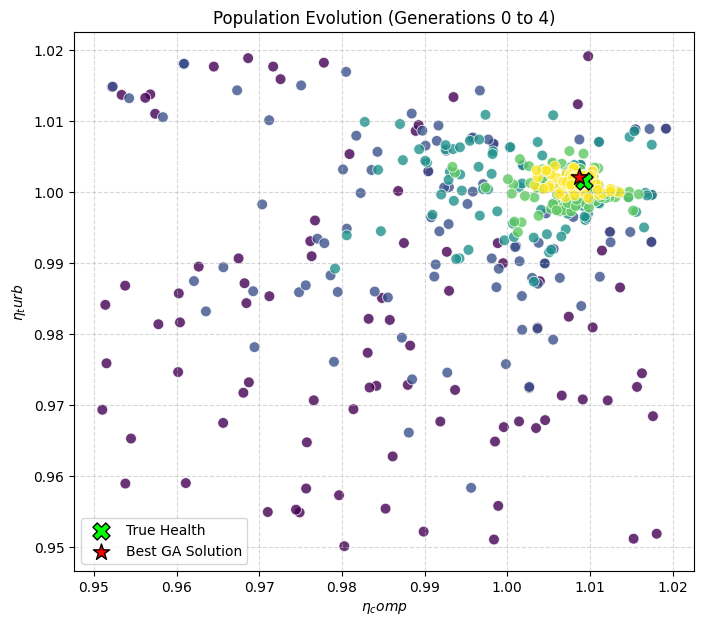

In [24]:
import time
import numpy as np

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
# true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5', 'W3R']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    # REMOVED: n_genes=3 (The class figures this out from 'bounds' automatically)
    pop_size=100,
    n_generations=20,
    bounds=[(0.95, 1.02), (0.95, 1.02), (0.95, 1.02)], # 3 tuples = 3 genes
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.0088202617298383, 1.002000786041836, 1.0048936899205287]
Target measurements: [1.79246835e+06 1.44332123e+03 3.00000000e+00]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(



STOPPING: Target fitness (-5.00) achieved at Generation 0.


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(



--- End of Evolution ---
Execution time: 27.43 s


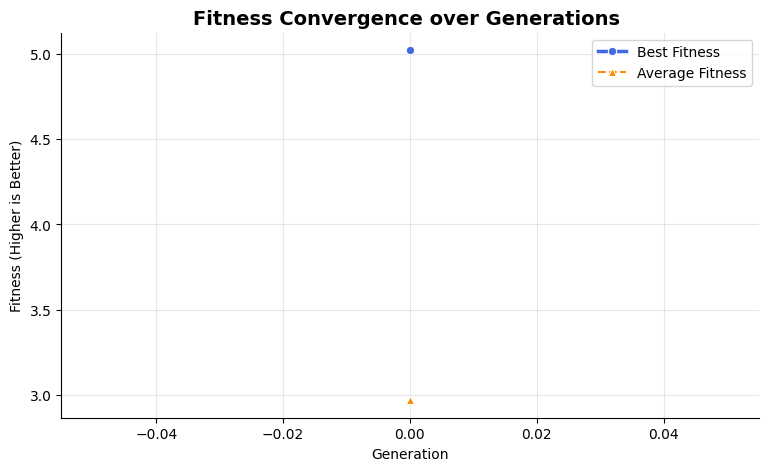

In [25]:
plot_convergence_seaborn(ga)